In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

---

In [3]:
# lab_raw.csv 로드
df = pd.read_csv('/content/drive/MyDrive/project/mini_20260109/data/processed/lab_raw.csv')

In [4]:
# 시간 컬럼을 날짜 형식으로 변환 (매우 중요)
df['charttime_h'] = pd.to_datetime(df['charttime_h'])

In [5]:
# 분석 전제 확인용
print("# 행과 열 개수 확인")
print(df.shape)
print("\n# 데이터타입 확인")
print(df.dtypes)

# 행과 열 개수 확인
(739339, 11)

# 데이터타입 확인
stay_id                 int64
charttime_h    datetime64[ns]
sao2                  float64
ph                    float64
lactate               float64
creatinine            float64
bilirubin             float64
wbc                   float64
platelets             float64
potassium             float64
sodium                float64
dtype: object


---
## STEP 0. 분석 단위 고정 (Analysis Contract)


In [6]:
print("[STEP 0] 분석 단위 확인")
print(f"- 전체 데이터 행 수: {len(df):,}")
print(f"- 대상 환자(Stay) 수: {df['stay_id'].nunique():,}")
print(f"- 포함된 변수: {df.columns.tolist()}")

[STEP 0] 분석 단위 확인
- 전체 데이터 행 수: 739,339
- 대상 환자(Stay) 수: 54,278
- 포함된 변수: ['stay_id', 'charttime_h', 'sao2', 'ph', 'lactate', 'creatinine', 'bilirubin', 'wbc', 'platelets', 'potassium', 'sodium']


---
## STEP 1. 데이터 시간순 정렬 확인

In [7]:
print("[STEP 1] 시간 정렬 샘플 확인 (정상 여부)")
# 한 환자의 첫 5시간 데이터를 봅니다.
display(df.sort_values(['stay_id', 'charttime_h']).head(5))

[STEP 1] 시간 정렬 샘플 확인 (정상 여부)


,stay_id,charttime_h,sao2,ph,lactate,creatinine,bilirubin,wbc,platelets,potassium,sodium
0,30000153,2174-09-29 13:00:00,NaN,7.30,1.3,NaN,NaN,NaN,NaN,NaN,NaN
1,30000153,2174-09-29 14:00:00,NaN,7.30,2.1,NaN,NaN,NaN,NaN,NaN,NaN
2,30000153,2174-09-29 15:00:00,NaN,NaN,NaN,0.9,NaN,17.0,173.0,4.4,142.0
3,30000153,2174-09-29 16:00:00,NaN,7.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,30000153,2174-09-30 03:00:00,NaN,NaN,NaN,1.1,NaN,15.2,162.0,4.8,145.0


---
## STEP 2: 시간당 측정 빈도(Data Density)


[STEP 2] 시간당 데이터 밀도 확인
- 환자 1인당 평균 관찰 시간: 13.6시간


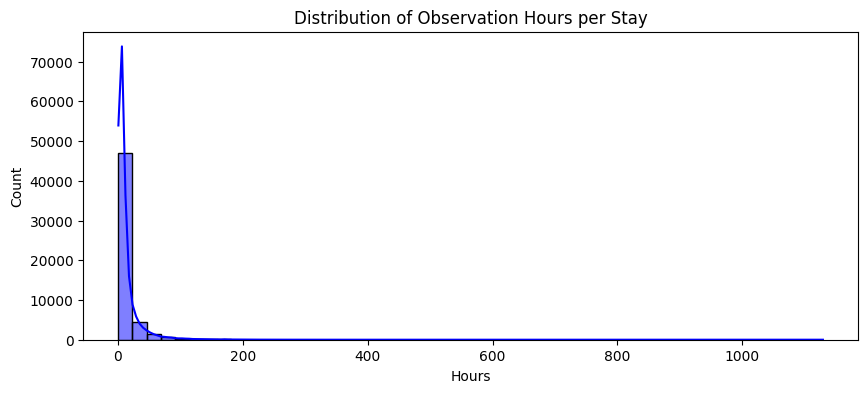

In [8]:
print("\n[STEP 2] 시간당 데이터 밀도 확인")
stay_counts = df.groupby('stay_id').size()
print(f"- 환자 1인당 평균 관찰 시간: {stay_counts.mean():.1f}시간")

plt.figure(figsize=(10, 4))
sns.histplot(stay_counts, bins=50, kde=True, color='blue')
plt.title("Distribution of Observation Hours per Stay")
plt.xlabel("Hours")
plt.show()

## STEP 3. 주요 수치 요약 및 이상치 (Outlier)


[STEP 3] 이상치 점검 (말 안 되는 수치 찾기)


,count,mean,std,min,25%,50%,75%,max
sao2,115733.0,85.868522,14.942103,50.0,73.00,94.00,97.00,100.0
ph,378677.0,7.374859,0.085487,6.8,7.33,7.38,7.43,7.8
lactate,212458.0,2.521309,2.388958,0.1,1.20,1.80,2.80,29.6
creatinine,387864.0,1.501697,1.445585,0.1,0.70,1.00,1.70,24.7
bilirubin,104366.0,3.252349,6.119089,0.1,0.50,0.90,2.80,50.0
wbc,345767.0,12.636489,7.482193,0.1,8.10,11.10,15.30,99.8
platelets,351973.0,196.976546,122.879660,5.0,113.00,174.00,252.00,1000.0
potassium,415893.0,4.122482,0.625455,1.5,3.70,4.00,4.40,10.0
sodium,414510.0,139.259522,5.954819,110.0,136.00,139.00,142.00,170.0


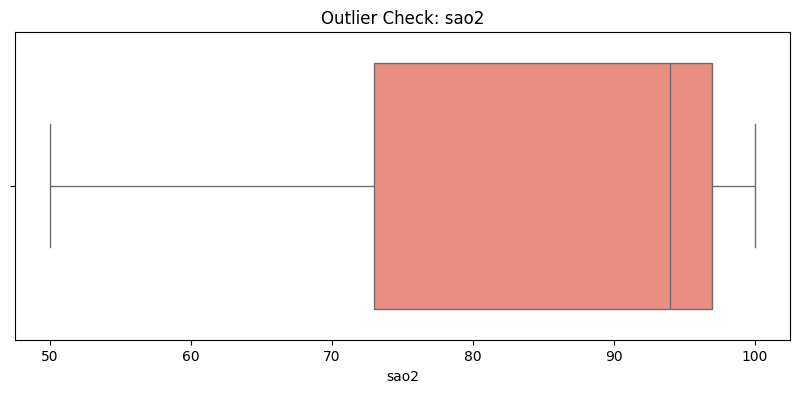

In [9]:
print("\n[STEP 3] 이상치 점검 (말 안 되는 수치 찾기)")
# 수치형 컬럼만 선택 (stay_id, charttime 제외)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('stay_id')
display(df[numeric_cols].describe().T)

# 대표 변수 하나를 골라 시각화 (예: 'hr' 또는 'glucose' 등)
target_col = numeric_cols[0] # 첫 번째 수치 컬럼 자동 선택
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x=target_col, color='salmon')
plt.title(f"Outlier Check: {target_col}")
plt.show()

---
## STEP 4: 시간 흐름 패턴 확인 (Trend)

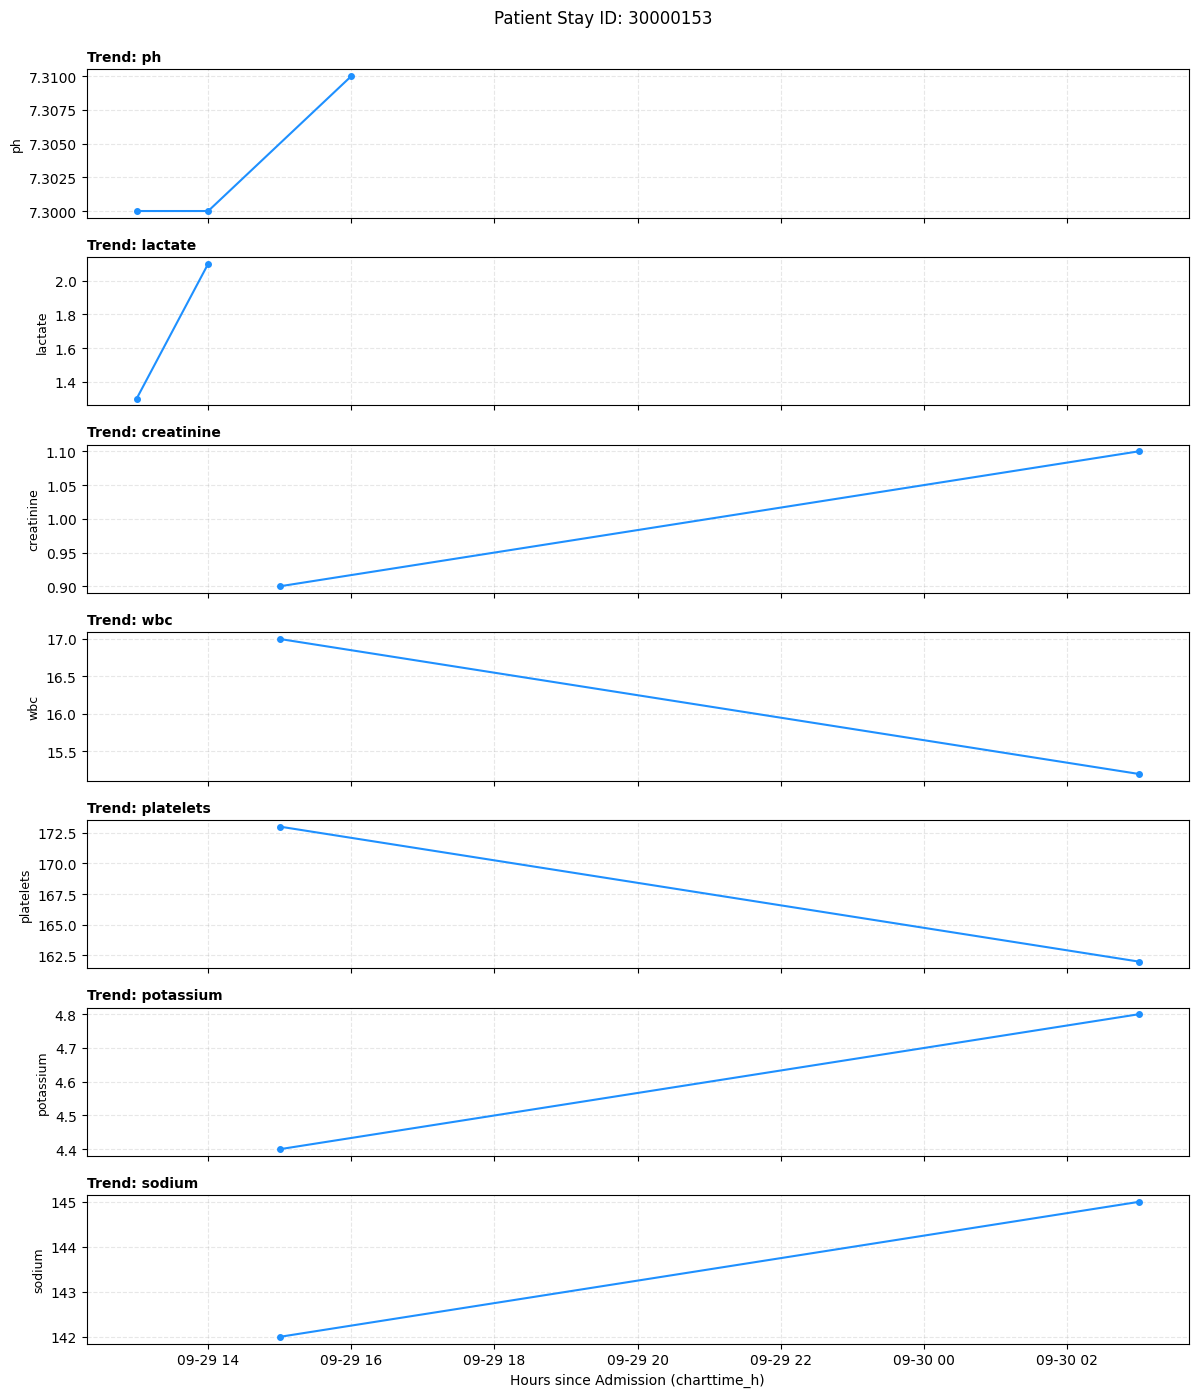

In [10]:
# 1. 데이터 검증 및 샘플 추출
if df.empty or 'stay_id' not in df.columns:
    raise ValueError("데이터프레임이 비어있거나 stay_id 컬럼이 없습니다")

unique_stays = df['stay_id'].dropna().unique()
if len(unique_stays) == 0:
    raise ValueError("유효한 stay_id가 없습니다")

sample_id = unique_stays[0]
sample_df = df[df['stay_id'] == sample_id].sort_values('charttime_h')

# 2. 분석할 컬럼 필터링
vital_cols = ['sao2', 'ph', 'lactate', 'creatinine', 'bilirubin', 'wbc', 'platelets', 'potassium', 'sodium']
available_cols = [col for col in vital_cols if col in sample_df.columns and not sample_df[col].dropna().empty]

if len(available_cols) == 0:
    raise ValueError("시각화할 유효한 데이터가 없습니다")

# 3. 시각화 (squeeze=False로 일관된 axes 처리)
fig, axes = plt.subplots(len(available_cols), 1, figsize=(12, 2 * len(available_cols)),
                         sharex=True, squeeze=False)
axes = axes.flatten()  # 항상 1D 배열로 변환

for i, col in enumerate(available_cols):
    data = sample_df[['charttime_h', col]].dropna()

    axes[i].plot(data['charttime_h'], data[col], marker='o', markersize=4,
                linestyle='-', color='dodgerblue', linewidth=1.5)
    axes[i].set_title(f"Trend: {col}", loc='left', fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_ylabel(col, fontsize=9)

    # 마지막 subplot에만 x축 레이블 추가
    if i == len(available_cols) - 1:
        axes[i].set_xlabel("Hours since Admission (charttime_h)", fontsize=10)

plt.suptitle(f"Patient Stay ID: {sample_id}", fontsize=12, y=0.995)
plt.tight_layout()
plt.show()


---
## STEP 5 & 6. 결측치 비율 및 패턴 (Missing Map)


[STEP 5/6] 결측치 비율 및 지도
bilirubin     85.883877
sao2          84.346423
lactate       71.263791
wbc           53.232955
platelets     52.393557
ph            48.781682
creatinine    47.539086
sodium        43.935056
potassium     43.747997
dtype: float64


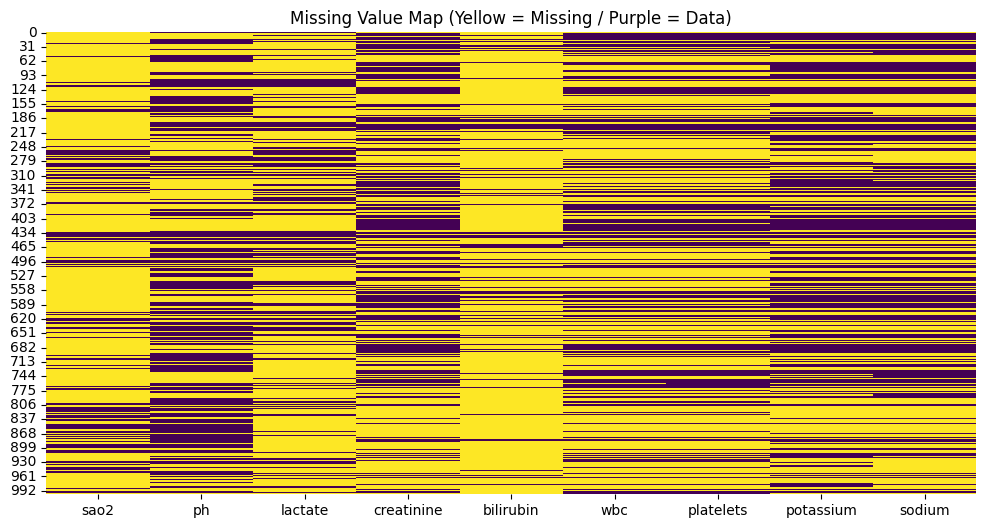

In [11]:
print("\n[STEP 5/6] 결측치 비율 및 지도")
missing_pct = df[numeric_cols].isnull().mean() * 100
print(missing_pct.sort_values(ascending=False))

plt.figure(figsize=(12, 6))
# 데이터가 너무 크면 일부만 샘플링하여 시각화
sns.heatmap(df[numeric_cols].iloc[:1000].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Map (Yellow = Missing / Purple = Data)")
plt.show()

---
## STEP 8. 결측과 상태의 관계 (Informative Missing)

In [12]:
print("\n[STEP 8] 결측의 정보성 확인")
# 예: 특정 변수가 비어있는 시간대와 그렇지 않은 시간대의 다른 수치 비교
df['is_missing'] = df[target_col].isnull()
# 두 번째 수치 컬럼이 있다면 그것과 비교
if len(numeric_cols) > 1:
    compare_col = numeric_cols[1]
    comparison = df.groupby('is_missing')[compare_col].mean()
    print(f"'{target_col}' 결측 여부에 따른 '{compare_col}' 평균 차이:")
    print(comparison)


[STEP 8] 결측의 정보성 확인
'sao2' 결측 여부에 따른 'ph' 평균 차이:
is_missing
False    7.373350
True     7.375396
Name: ph, dtype: float64


---
## STEP 9. 최종 판정 (Go/No-Go)

In [13]:
print("[STEP 9] Sliding Window 투입 가능 여부 판단")
min_hours = stay_counts.min()
if min_hours >= 24: # 우리 코호트 기준이 24시간 이상 체류라면
    print(f"✅ PASS: 모든 환자가 최소 {min_hours}시간 이상의 데이터를 보유함.")
else:
    print(f"⚠️ WARNING: 데이터가 {min_hours}시간 미만인 환자가 존재함. 필터링 필요 여부 확인!")

print("\nEDA 검증 완료.")

[STEP 9] Sliding Window 투입 가능 여부 판단
⚠️ WARNING: 데이터가 1시간 미만인 환자가 존재함. 필터링 필요 여부 확인!

EDA 검증 완료.


In [14]:
# 0. 사전 검증
required_cols = ['stay_id', 'charttime_h']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"필수 컬럼이 누락되었습니다: {missing_cols}")

# 1. 환자별 체류 시간(Duration) 계산
# charttime_h가 datetime일 경우, (최대값 - 최소값)으로 실제 체류 시간을 구합니다.
stay_summary = df.groupby('stay_id')['charttime_h'].agg(['min', 'max', 'count'])
stay_summary['max_hours'] = (stay_summary['max'] - stay_summary['min']).dt.total_seconds() / 3600
stay_summary.columns = ['first_time', 'last_time', 'record_count', 'max_hours']

short_stays = stay_summary[stay_summary['max_hours'] < 24].index

if len(short_stays) > 0:
    print(f"⚠️ {len(short_stays)}명의 환자가 24시간 미만의 데이터를 보유하고 있습니다.")
    print(f"   (전체 환자 수: {len(stay_summary)}명, 비율: {len(short_stays)/len(stay_summary)*100:.1f}%)\n")

    # 체류 시간 통계 (이제 max_hours는 숫자형이므로 정상 작동합니다)
    short_stats = stay_summary.loc[short_stays, 'max_hours']
    print(f"📊 24시간 미만 환자 체류 시간 통계:")
    print(f"   - 평균: {short_stats.mean():.2f}시간")
    print(f"   - 중앙값: {short_stats.median():.2f}시간")
    print(f"   - 최소: {short_stats.min():.2f}시간")
    print(f"   - 최대: {short_stats.max():.2f}시간\n")

    # 2. 컬럼별 유효 데이터 개수 확인 (이하 동일)
    vital_cols = ['sao2', 'ph', 'lactate', 'creatinine', 'bilirubin', 'wbc', 'platelets', 'potassium', 'sodium']
    available_cols = [col for col in vital_cols if col in df.columns]

    if available_cols:
        short_stay_df = df[df['stay_id'].isin(short_stays)]
        missing_report = short_stay_df.groupby('stay_id')[available_cols].count()

        print("📋 [컬럼별 유효 데이터 개수 - 상위 10명]")
        print(missing_report.head(10).to_string())
        print()

        print("📉 [지표별 데이터 부재 환자 통계]")
        summary_data = []
        for col in available_cols:
            no_data_count = (missing_report[col] == 0).sum()
            has_data_count = (missing_report[col] > 0).sum()
            avg_records = missing_report[col].mean()
            summary_data.append({
                '지표': col,
                '데이터 없음': no_data_count,
                '데이터 있음': has_data_count,
                '평균 레코드 수': f"{avg_records:.1f}"
            })

        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
else:
    print("✅ 모든 환자가 24시간 이상의 데이터를 충실히 보유하고 있습니다.")


⚠️ 12918명의 환자가 24시간 미만의 데이터를 보유하고 있습니다.
   (전체 환자 수: 54278명, 비율: 23.8%)

📊 24시간 미만 환자 체류 시간 통계:
   - 평균: 12.75시간
   - 중앙값: 15.00시간
   - 최소: 0.00시간
   - 최대: 23.00시간

📋 [컬럼별 유효 데이터 개수 - 상위 10명]
          sao2  ph  lactate  creatinine  bilirubin  wbc  platelets  potassium  sodium
stay_id                                                                              
30000153     0   3        2           2          0    2          2          2       2
30001148     3   6        1           2          0    3          3          2       1
30001396     1   1        1           2          2    2          2          2       2
30001446     0   1        1           3          3    3          3          3       3
30001471     0   0        0           2          1    2          2          2       2
30001656     0   0        0           1          0    1          1          1       2
30001947     0   2        1           5          1    2          2          5       5
30002415     1   5        1       